1 Setup libraries

In [1]:
import json
import pandas as pd
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [2]:

# Define file paths (this is my path, change to your)
input_file = r"C:\Users\ADMIN\Documents\Algorithm_Inno\ML\data\data_processed.json"
output_file = r"C:\Users\ADMIN\Documents\Algorithm_Inno\ML\data\data_labeled.json"

2 Read data

In [18]:
# Read data
df = pd.read_json(input_file)

if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

df.head() 


,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Tx_to_Balance_Ratio,Hour,DayOfWeek
0,TXN_300001,ACC_09194,REC_3448,0.087034,2025-12-28 08:59:00,5,2,0,2,3,0.262525,0,5,0.844444,0.463415,0.030553,0.000679,8,6
1,TXN_300001,ACC_09194,REC_3448,0.087034,2025-12-28 08:59:00,5,2,0,0,3,0.122244,0,0,0.933333,0.097561,0.013008,0.001451,8,6
2,TXN_300002,ACC_04160,REC_1969,0.766979,2025-05-27 14:30:00,2,0,1,0,6,0.971944,3,0,0.822222,0.317073,0.115758,0.001598,14,1
3,TXN_300003,ACC_00529,REC_8713,0.520959,2025-06-12 21:53:00,6,1,3,1,4,0.378758,4,4,0.933333,0.414634,0.040302,0.002784,21,3
4,TXN_300004,ACC_05993,REC_2068,0.096763,2025-06-11 14:34:00,3,2,1,0,4,0.454910,3,1,0.311111,0.756098,0.120053,0.000435,14,2


3 Picking features 

In [19]:
features = [
    'Transaction amount', 'Account balance', 'Salary (per month)',
    'Hour', 'DayOfWeek', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Tx_to_Balance_Ratio',
    'Transaction Detail', 'Geological', 'Device Use', 
    'Location', 'Working Status', 'Gender', 'Transaction Count'
]

selected_features = [col for col in features if col in df.columns]
X = df[selected_features]

4 Train model

In [20]:
model = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.15
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


Number of Anomalies

In [21]:
predictions = model.predict(X)
df['is_fraud'] = [1 if p == -1 else 0 for p in predictions]
df['anomaly_score'] = model.score_samples(X)

print(f"Found {df['is_fraud'].sum()} suspicious transactions.")


Found 4266 suspicious transactions.


5 Saving result to json file (data_labeled)

In [22]:

if 'DateTime' in df.columns:
    df['DateTime'] = df['DateTime'].astype(str)
elif 'Timestamp' in df.columns:
    df['Timestamp'] = df['Timestamp'].astype(str)
    
df.to_json(output_file, orient='records', indent=4, force_ascii=False)


6 Visualization


6.1 Anomaly Score Distribution (most important)

Plot a histogram of anomaly_score. You'll see a bimodal distribution — normal transactions cluster on the right (scores near 0), anomalies cluster on the left (very negative scores).

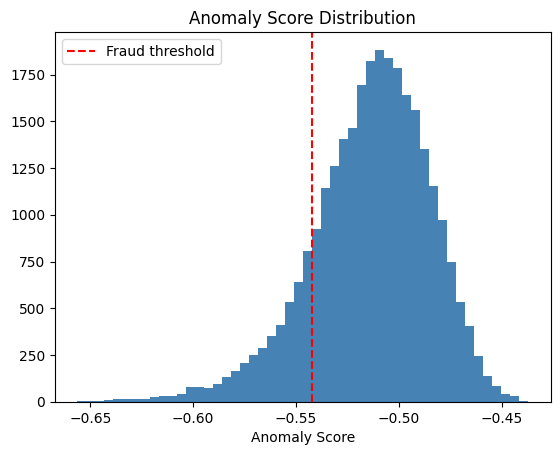

In [10]:
import matplotlib.pyplot as plt
plt.hist(df['anomaly_score'], bins=50, color='steelblue')
plt.axvline(df[df['is_fraud']==1]['anomaly_score'].max(), color='red', linestyle='--', label='Fraud threshold')
plt.title('Anomaly Score Distribution')
plt.xlabel('Anomaly Score'); plt.legend(); plt.show()

6.2 Fraud vs Normal Count (Bar Chart)
    Simple but effective — shows how many transactions were flagged.

Text(0.5, 1.0, 'Normal vs Fraud Count')

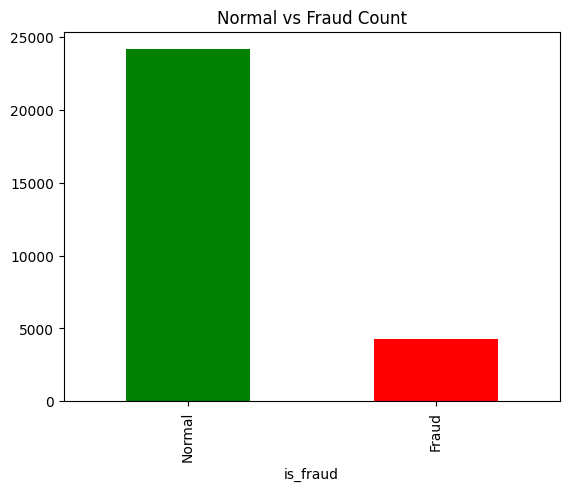

In [11]:
df['is_fraud'].value_counts().rename({0:'Normal', 1:'Fraud'}).plot(kind='bar', color=['green','red'])
plt.title('Normal vs Fraud Count')


6.3 Transaction Amount vs Account Balance (Scatter Plot)
    Color points by is_fraud to see if anomalies cluster in specific regions (e.g., huge amounts with low balance).

Text(0.5, 1.0, 'Transaction Amount vs Account Balance')

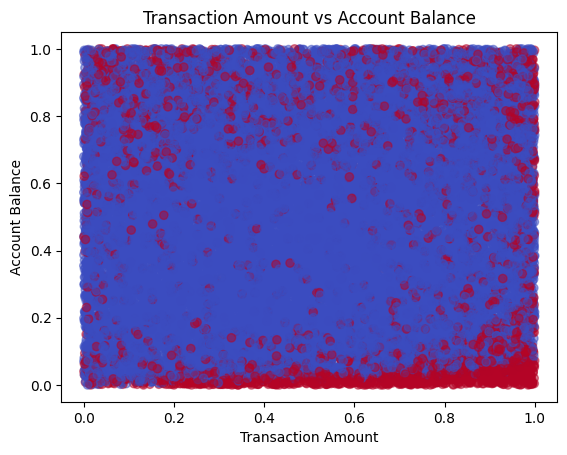

In [13]:
plt.scatter(df['Transaction amount'], df['Account balance'], c=df['is_fraud'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Transaction Amount'); plt.ylabel('Account Balance')
plt.title('Transaction Amount vs Account Balance')


6.4 Anomaly Heatmap by Hour and Day of Week
    Shows when fraud happens — useful since code extracts Hour and DayOfWeek.

Text(0.5, 1.0, 'Fraud Heatmap: Hour vs Day of Week')

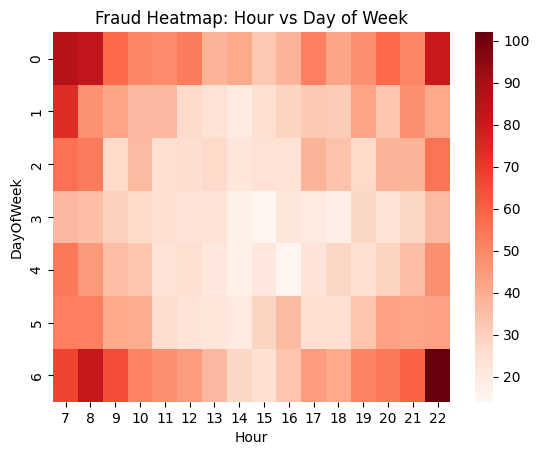

In [23]:
import seaborn as sns
pivot = df[df['is_fraud']==1].groupby(['DayOfWeek','Hour']).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap='Reds')
plt.title('Fraud Heatmap: Hour vs Day of Week')
